<a href="https://colab.research.google.com/github/heisenberg304/aprendiendo-ml-cloud/blob/semana-6/dia%205.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_8147/263378825.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["trestbps"].fillna(data["trestbps"].median(), inplace=True)
/tmp/ipykernel_8147/263378825.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

modelo underfitting
mean -> 0.6043478260869566
std -> 0.11001374720765211
train score -> 0.7622282608695652
gap -> 0.1578804347826086

      
modelo overfitting
mean -> 0.6793478260869565
std -> 0.024546934327470033
train score -> 0.8872282608695652
gap -> 0.20788043478260865

      
modelo balanceado
mean -> 0.7695652173913043
std -> 0.07782183617247282
train score -> 0.8342391304347826
gap -> 0.06467391304347825


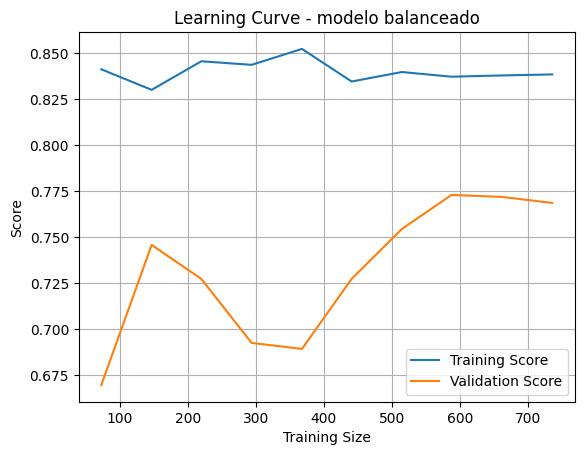

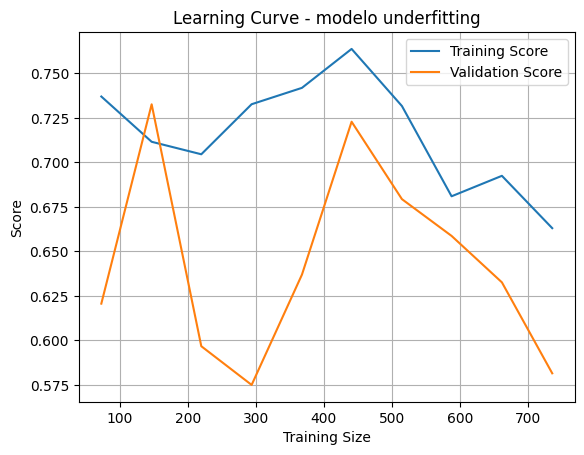

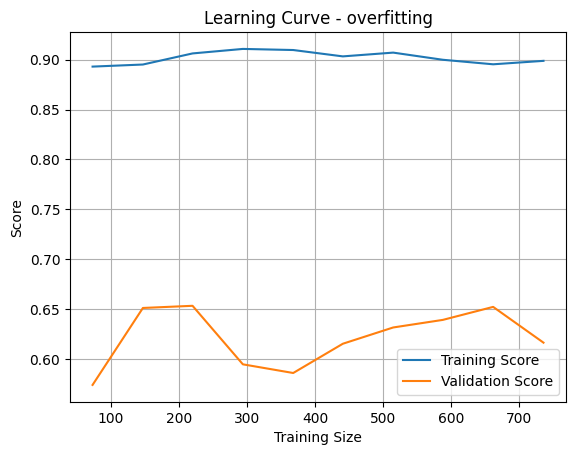

In [20]:

#Cargar librerias
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

#Cargar dataset
data = pd.read_csv("/content/drive/MyDrive/data_csv/heart_disease_uci.csv")

#===================================================================================================================================================================================================

#MANIPULAR CSV
  #rellenar: trestbps(59)(median o mean), chol(30)(median), fbs(90)(mode), restecg(2)(mode), thalch(55)(median o mean), oldpeak(62)(median)
data["trestbps"].fillna(data["trestbps"].median(), inplace=True)
data["chol"].fillna(data["chol"].median(), inplace=True)
data["fbs"].fillna(data["fbs"].mode()[0], inplace=True)
data["restecg"].fillna(data["restecg"].mode()[0], inplace=True)
data["thalch"].fillna(data["thalch"].median(), inplace=True)
data["oldpeak"].fillna(data["oldpeak"].median(), inplace=True)

  #target binario
data["num"] = data["num"].apply(lambda x: 1 if x > 0 else 0)

  #encoding: sex, cp, restecg, num (target)
fe_ma = pd.get_dummies(data["sex"])
CP = pd.get_dummies(data["cp"])
RESTECG = pd.get_dummies(data["restecg"])

  #union de datasets
data = pd.concat([data, fe_ma, CP, RESTECG], axis=1)
  #borrar columnas
data = data.drop(["id", "dataset", "slope", "ca", "thal", "sex", "cp", "restecg"], axis=1)

#===================================================================================================================================================================================================

#crear x and y
x = data[['age','trestbps','chol','fbs','thalch','exang',
          'oldpeak','Female','Male','asymptomatic',
          'atypical angina','non-anginal','typical angina',
          'lv hypertrophy','normal','st-t abnormality']]
y = data["num"]

#split 80/20
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=55
)

#===================================================================================================================================================================================================

#CREAR MODELOS
  #modelo underfitting
model_under = RandomForestClassifier(n_estimators=1,
                               max_depth=1,
                               min_samples_leaf=1)
  #modelo overfitting
model_over = RandomForestClassifier(n_estimators=2,
                               max_depth=None,
                               min_samples_leaf=1)
  #modelo balanceado
model = RandomForestClassifier(n_estimators=200,
                               max_depth=5,
                               min_samples_leaf=15)


#entrenar modelo underfitting
model_under.fit(x_train, y_train)
#entrenar modelo overfitting
model_over.fit(x_train, y_train)
#entrenar modelo balanceado
model.fit(x_train, y_train)


#train_score, usar train en vez de test en predict
  #modelo underfitting
probs_train = model_under.predict_proba(x_train)[:, 1]
threshold = 0.5
pred_train_under = (probs_train >= threshold).astype(int)
  #modelo overfitting
probs_train = model_over.predict_proba(x_train)[:, 1]
threshold = 0.5
pred_train_over = (probs_train >= threshold).astype(int)
  #modelo balanceado
probs_train = model.predict_proba(x_train)[:, 1]
threshold = 0.5
pred_train = (probs_train >= threshold).astype(int)


#TRAIN SCORES
  #modelo underfitting
train_score_under = accuracy_score(y_train, pred_train_under)
  #modelo overfitting
train_score_over = accuracy_score(y_train, pred_train_over)
  #modelo balanceado
train_score = accuracy_score(y_train, pred_train)

#===================================================================================================================================================================================================

#VALIDACION CRUZADA
  #modelo underfitting
scores_under = cross_val_score(
    model_under,
    x,
    y,
    cv=5
)
  #modelo overfitting
scores_over = cross_val_score(
    model_over,
    x,
    y,
    cv=5
)
  #modelo balanceado
scores = cross_val_score(
    model,
    x,
    y,
    cv=5
)

print(f"""modelo underfitting
mean -> {scores_under.mean()}
std -> {scores_under.std()}
train score -> {train_score_under}
gap -> {train_score_under - scores_under.mean()}

      """)

print(f"""modelo overfitting
mean -> {scores_over.mean()}
std -> {scores_over.std()}
train score -> {train_score_over}
gap -> {train_score_over - scores_over.mean()}

      """)

print(f"""modelo balanceado
mean -> {scores.mean()}
std -> {scores.std()}
train score -> {train_score}
gap -> {train_score - scores.mean()}""")

#===================================================================================================================================================================================================

#modelo underfitting
train_sizes_under, train_scores_under, val_scores_under = learning_curve(
    model_under,
    x,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean_under = np.mean(train_scores_under, axis=1)
val_mean_under = np.mean(val_scores_under, axis=1)

#modelo overfitting
train_sizes_over, train_scores_over, val_scores_over = learning_curve(
    model_over,
    x,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean_over = np.mean(train_scores_over, axis=1)
val_mean_over = np.mean(val_scores_over, axis=1)

#modelo balanceado
train_sizes_bal, train_scores_bal, val_scores_bal = learning_curve(
    model,
    x,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean_bal = np.mean(train_scores_bal, axis=1)
val_mean_bal = np.mean(val_scores_bal, axis=1)

#GRAFICAR
#modelo balanceado
plt.plot(train_sizes_bal, train_mean_bal, label="Training Score")
plt.plot(train_sizes_bal, val_mean_bal, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve - modelo balanceado")
plt.legend()
plt.grid()
plt.show()

#modelo underfitting
plt.plot(train_sizes_under, train_mean_under, label="Training Score")
plt.plot(train_sizes_under, val_mean_under, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve - modelo underfitting")
plt.legend()
plt.grid()
plt.show()

#modelo overfitting
plt.plot(train_sizes_over, train_mean_over, label="Training Score")
plt.plot(train_sizes_over, val_mean_over, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.title("Learning Curve - overfitting")
plt.legend()
plt.grid()
plt.show()